In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Total statements per LLM per prompt

In [15]:
df = pd.read_excel('Gen-BS.xlsx')
table = pd.crosstab(df["Prompt"], df["Model"], margins=True)
table.index = ["Prompt 1", "Prompt 2", "Total"]

print(table)

Model     GPT  Gemini  All
Prompt 1   51      53  104
Prompt 2   65      82  147
Total     116     135  251


# Total and avg claims per person and model

In [16]:
df = pd.read_excel('Gen-BS.xlsx')

# total claims
claims = df.groupby(["Person", "Model"]).size().unstack(fill_value=0)

# average per prompt
avg = claims / 2

# combine tables
table = pd.concat([claims, avg], axis=1)

# add total row
table.loc["Total"] = [
    claims["GPT"].sum(),
    claims["Gemini"].sum(),
    round(avg["GPT"].mean(), 1),
    round(avg["Gemini"].mean(), 1)
]

# rename columns
table.columns = [
    "GPT total",
    "Gemini total",
    "GPT avg",
    "Gemini avg"
]

print(table.round(1))

           GPT total  Gemini total  GPT avg  Gemini avg
Person                                                 
Christian       24.0          43.0     12.0        21.5
David           37.0          36.0     18.5        18.0
Lucie           32.0          33.0     16.0        16.5
Matus           23.0          23.0     11.5        11.5
Total          116.0         135.0     14.5        16.9


# Claims per person and model plot

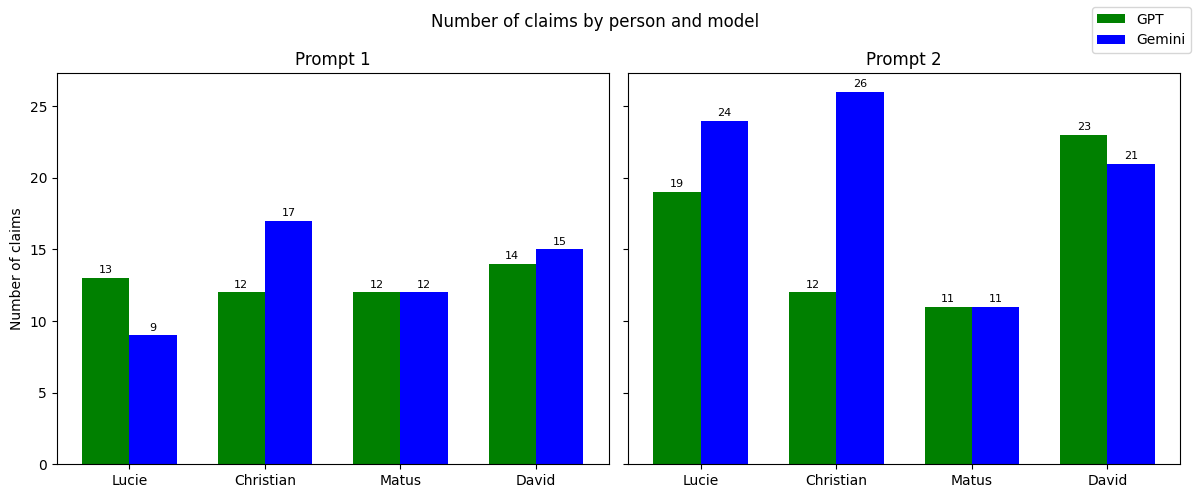

In [17]:
df = pd.read_excel('Gen-BS.xlsx')

# count claims
counts = (
    df.groupby(["Prompt", "Person", "Model"])
      .size()
      .unstack(fill_value=0)
)

people = ["Lucie", "Christian", "Matus", "David"]

# split prompts
p1 = counts.loc[1].reindex(people)
p2 = counts.loc[2].reindex(people)

x = np.arange(len(people))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = ["green", "blue"]  # GPT green, Gemini blue

# ----- Prompt 1 -----
axes[0].bar(x - width/2, p1["GPT"], width, label="GPT", color=colors[0])
axes[0].bar(x + width/2, p1["Gemini"], width, label="Gemini", color=colors[1])

axes[0].set_title("Prompt 1")
axes[0].set_xticks(x)
axes[0].set_xticklabels(people)
axes[0].set_ylabel("Number of claims")

# ----- Prompt 2 -----
axes[1].bar(x - width/2, p2["GPT"], width, color=colors[0])
axes[1].bar(x + width/2, p2["Gemini"], width, color=colors[1])

axes[1].set_title("Prompt 2")
axes[1].set_xticks(x)
axes[1].set_xticklabels(people)

# add numbers above bars
for ax, data in zip(axes, [p1, p2]):
    for container in ax.containers:
        ax.bar_label(container, padding=2, fontsize=8)

# overall title + legend
fig.suptitle("Number of claims by person and model")
fig.legend(["GPT", "Gemini"], loc="upper right")

plt.tight_layout()
plt.show()

# Domain distribution by prompt

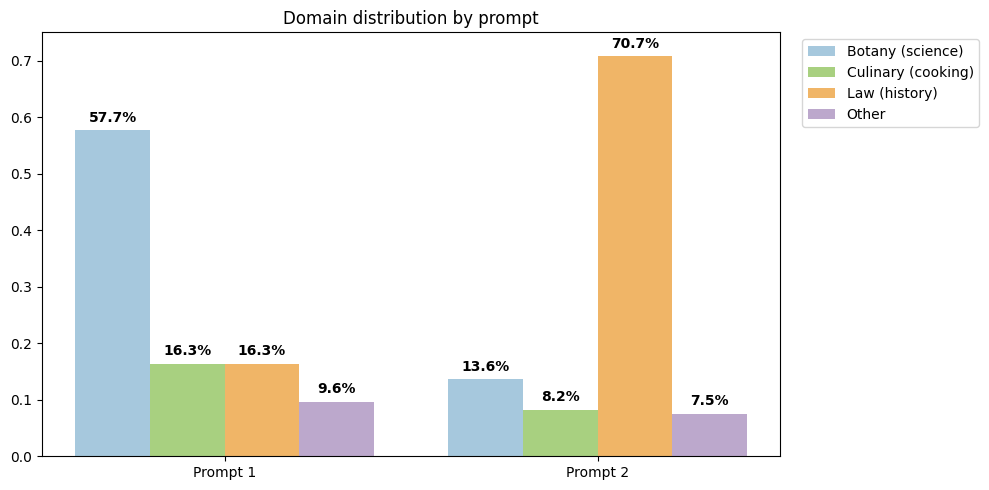

In [18]:
df = pd.read_excel('Gen-BS.xlsx')

# calculate proportions
domain_dist = pd.crosstab(
    df["Prompt"],
    df["Domain"],
    normalize="index"
)

# keep column order
domain_dist = domain_dist[[
    "Botany (science)",
    "Culinary (cooking)",
    "Law (history)",
    "Other"
]]

x = np.arange(len(domain_dist.index))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))

colors = [
    "#a6c8dd",  # light blue
    "#a8d080",  # light green
    "#f0b567",  # orange
    "#bca8cc"   # purple
]

# create grouped bars
for i, column in enumerate(domain_dist.columns):
    bars = ax.bar(
        x + (i - 1.5) * width,
        domain_dist[column],
        width,
        label=column,
        color=colors[i]
    )

    # percentage labels
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height*100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(["Prompt 1", "Prompt 2"])

ax.set_title("Domain distribution by prompt")
ax.set_ylim(0, 0.75)

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

# Average claim length

In [19]:
df = pd.read_excel("Gen-BS.xlsx")

# count words in each statement
df["Word count"] = df["Statement"].str.split().str.len()

# average per model
table = (
    df.groupby("Model")["Word count"]
      .mean()
      .round(1)
      .to_frame(name="Average statement length (words)")
)

print(table)

        Average statement length (words)
Model                                   
GPT                                 10.0
Gemini                              13.7


# Statements by source

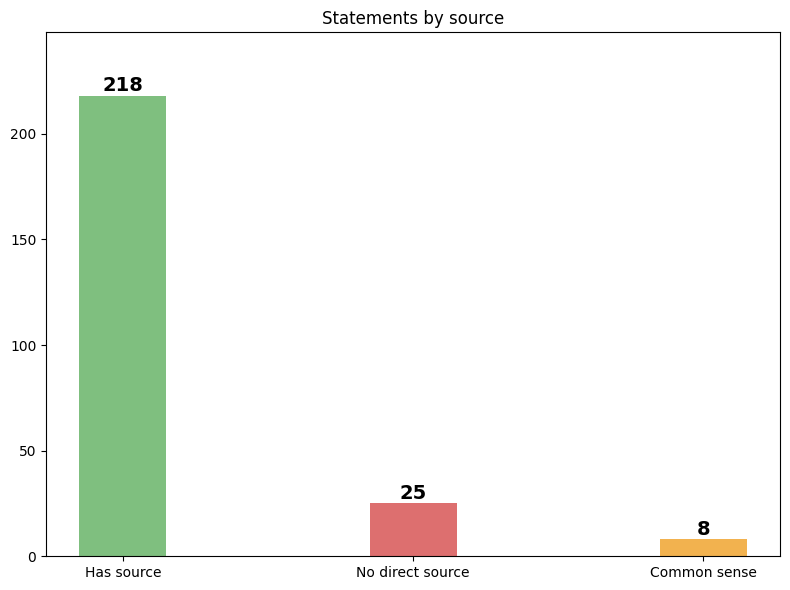

In [ ]:
df = pd.read_excel("Gen-BS.xlsx")

# classify sources
df["Source type"] = df["Source"].apply(
    lambda x:
        "No direct source" if x == "No direct source"
        else "Common sense" if x == "Common sense"
        else "Has source"
)

# count categories
counts = df["Source type"].value_counts()

# keep order
counts = counts.reindex([
    "Has source",
    "No direct source",
    "Common sense"
])

colors = ["#7fbf7f", "#dd6f6f", "#f2b24f"]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(counts.index, counts.values, color=colors, width=0.3)

# numbers above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        int(height),
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

ax.set_title("Statements by source")
ax.set_ylim(0, max(counts.values) + 30)

plt.tight_layout()
plt.show()

# False statements

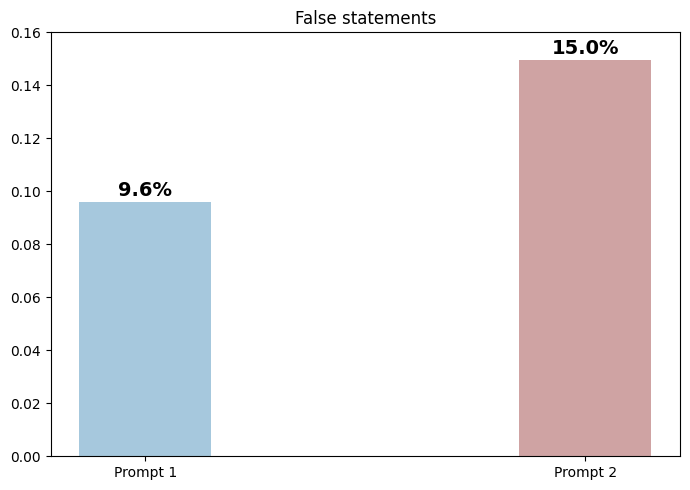

In [ ]:
df = pd.read_excel("Gen-BS.xlsx")

# clean correctness column
df["Correctness"] = (
    df["Correctness"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# calculate false rate
false_rates = (
    df.groupby("Prompt")["Correctness"]
      .apply(lambda x: (x == "FALSE").mean())
)

colors = ["#a6c8dd", "#cfa3a3"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["Prompt 1", "Prompt 2"],
    false_rates.values,
    color=colors,
    width=0.3
)

# labels
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height*100:.1f}%",
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

ax.set_title("False statements")
ax.set_ylim(0, 0.16)

plt.tight_layout()
plt.show()